# Machine Learning Classification using Multiple Algorithms
## Dataset: Heart Disease Prediction Dataset
## Algorithms: SVM, Decision Tree, KNN

## a) Problem Statement

The objective of this experiment is to predict the presence of heart disease using clinical attributes.
Machine learning algorithms such as Support Vector Machine (SVM), Decision Tree (DT), and K-Nearest Neighbours (KNN) are implemented.

Models will be evaluated using:

- Accuracy
- Sensitivity (Recall)
- Specificity
- F1 Score
- ROC Curve
- AUC Score

## b) Dataset Used

Dataset Name: Heart Disease Prediction Dataset

Repository Link:
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Target Column: target  
0 = No Disease  
1 = Disease

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
X = df.drop("target", axis=1)
y = df["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## c) ML Algorithm Used: Support Vector Machine (SVM)

In [8]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [9]:
acc = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
specificity = TN/(TN+FP)

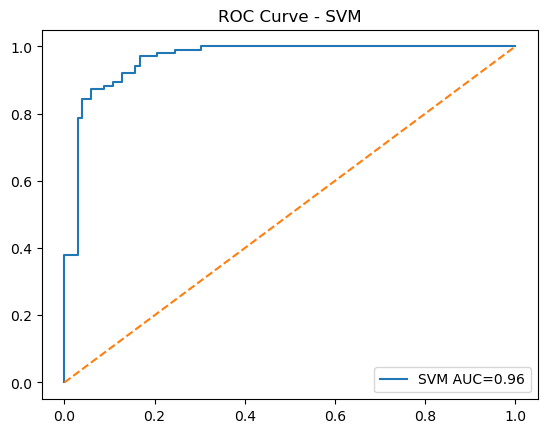

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr,tpr,label="SVM AUC=%0.2f"%auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

## c) ML Algorithm Used: Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [12]:
acc_dt = accuracy_score(y_test, y_pred_dt)
sensitivity_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

cm_dt = confusion_matrix(y_test, y_pred_dt)
TN, FP, FN, TP = cm_dt.ravel()
specificity_dt = TN/(TN+FP)

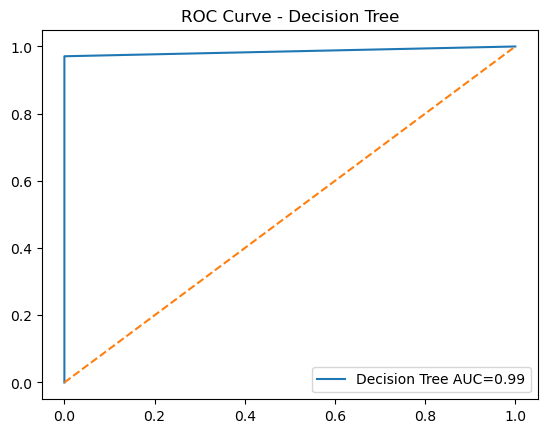

In [13]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.plot(fpr_dt,tpr_dt,label="Decision Tree AUC=%0.2f"%auc_dt)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

## c) ML Algorithm Used: K-Nearest Neighbours (KNN)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

In [15]:
acc_knn = accuracy_score(y_test, y_pred_knn)
sensitivity_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)
TN, FP, FN, TP = cm_knn.ravel()
specificity_knn = TN/(TN+FP)

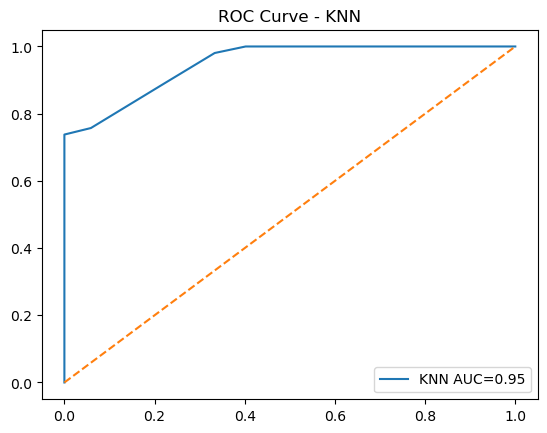

In [16]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.plot(fpr_knn,tpr_knn,label="KNN AUC=%0.2f"%auc_knn)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

## d) Result & Discussion

All three models were compared using Accuracy, Sensitivity, Specificity, F1 Score and AUC.

SVM generally provides stable ROC performance, Decision Tree offers interpretability, and KNN provides distance-based classification.

In [17]:
comparison_table = pd.DataFrame({
"Model":["SVM","Decision Tree","KNN"],
"Accuracy":[acc,acc_dt,acc_knn],
"Sensitivity":[sensitivity,sensitivity_dt,sensitivity_knn],
"Specificity":[specificity,specificity_dt,specificity_knn],
"F1 Score":[f1,f1_dt,f1_knn],
"AUC":[auc,auc_dt,auc_knn]
})

comparison_table

,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,SVM,0.887805,0.941748,0.833333,0.894009,0.963164
1,Decision Tree,0.985366,0.970874,1.000000,0.985222,0.985437
2,KNN,0.834146,0.893204,0.774510,0.844037,0.948553
